# Setup

In [ ]:
from sliced_normals.combine_groups.optimize import *

# Helper Functions

## Individual Group Optimization

In [4]:
def save_or_load_B_opt(data, degree, n_grid, verbosity, penalty_lambda,
                       winsor_threshold, max_iterations, min_gradient_norm,
                       seed=None, folder='temp_files'):
    """
    Loads B_opt from cache if available for the same data content, column names,
    seed, and parameters; otherwise computes and saves it using a hash-based identifier.

    Parameters:
        data : pd.DataFrame or np.ndarray
        seed : int or None, used for reproducibility if stochastic elements exist
        All other arguments are optimization parameters

    Returns:
        B_opt : np.ndarray
    """
    os.makedirs(folder, exist_ok=True)

    # Convert data to array and capture column names if present
    data_array = np.asarray(data)
    col_names = list(data.columns) if hasattr(data, "columns") else []

    # Build parameter dictionary including seed and column names
    param_dict = {
        "data_hash": hashlib.md5(data_array.tobytes()).hexdigest(),
        "column_names": col_names,
        "degree": degree,
        "n_grid": n_grid,
        "verbosity": verbosity,
        "penalty_lambda": penalty_lambda,
        "winsor_threshold": winsor_threshold,
        "max_iterations": max_iterations,
        "min_gradient_norm": min_gradient_norm,
        "seed": seed
    }

    # Generate unique hash
    param_bytes = pickle.dumps(param_dict)
    param_hash = hashlib.md5(param_bytes).hexdigest()

    # File paths
    b_path = os.path.join(folder, f'B_opt_{param_hash}.pkl')
    p_path = os.path.join(folder, f'params_{param_hash}.pkl')

    # Load if already computed
    if os.path.exists(b_path) and os.path.exists(p_path):
        with open(b_path, 'rb') as f:
            B_opt = pickle.load(f)
        print(f"✅ Loaded B_opt from cache: {b_path}")
    else:
        print("🔁 Computing B_opt (no cache found)...")
        if seed is not None:
            np.random.seed(seed)
        B_opt = estimate_optimal_B(
            data,
            degree=degree,
            n_grid=n_grid,
            verbosity=verbosity,
            penalty_lambda=penalty_lambda,
            winsor_threshold=winsor_threshold,
            max_iterations=max_iterations,
            min_gradient_norm=min_gradient_norm
        )
        with open(b_path, 'wb') as f:
            pickle.dump(B_opt, f)
        with open(p_path, 'wb') as f:
            pickle.dump(param_dict, f)
        print(f"✅ Saved B_opt and parameters to: {b_path}")

    return B_opt


## Combine subgroups

### Main Optimization Function

### High level wrappers

In [5]:

# -----------------------------------------------------------
# 3.  High-level wrapper that builds the full B-matrix
#     (updated for the NEW centered formulation)
# -----------------------------------------------------------
def combine_B_blocks_reparam(B1, B2,
                             data1, data2,
                             degree=2, n_grid=10000,
                             verbosity=2, max_iterations=1000,
                             min_gradient_norm=1e-4,
                             winsor_threshold=1e-10,
                             n_restarts=1,
                             return_details=False):
    """
    Combines two fitted block matrices B1, B2 by optimizing the cross-block P12
    using the NEW reparameterized objective (centered formulation).

    Returns
    -------
    mu : ndarray
        Combined mean vector [mu1, mu2].
    P : ndarray
        Combined precision matrix [[P11, P12], [P12^T, P22]].
    (optional) details : dict
        Diagnostics from estimate_optimal_P12_reparam if return_details=True.
    """

    # ----- 3.1  Extract block pieces from the two FMLE blocks -----
    p1 = B1.shape[0] - 1
    p2 = B2.shape[0] - 1

    # Precision blocks from B
    P11 = 2.0 * B1[1:1 + p1, 1:1 + p1]
    P22 = 2.0 * B2[1:1 + p2, 1:1 + p2]

    P11_inv = inv(P11)
    P22_inv = inv(P22)

    # Means implied by B blocks
    mu1 = -2.0 * B1[0, 1:1 + p1] @ P11_inv
    mu2 = -2.0 * B2[0, 1:1 + p2] @ P22_inv
    mu = np.concatenate([mu1, mu2])

    # ----- 3.2  Feature matrices & integration grids -------------
    if not isinstance(data1, pd.DataFrame):
        data1 = pd.DataFrame(data1, columns=[f"X1_{i}" for i in range(data1.shape[1])])
    if not isinstance(data2, pd.DataFrame):
        data2 = pd.DataFrame(data2, columns=[f"X2_{i}" for i in range(data2.shape[1])])

    Z1_df, Z1g_df, vol1 = get_F_and_Random_Samples(data1, degree, n_grid)
    Z2_df, Z2g_df, vol2 = get_F_and_Random_Samples(data2, degree, n_grid)

    # Keep feature columns only (drop intercept column)
    Z1  = np.asarray(Z1_df.iloc[:, 1:], dtype=np.float64)
    Z2  = np.asarray(Z2_df.iloc[:, 1:], dtype=np.float64)
    Z1g = np.asarray(Z1g_df.iloc[:, 1:], dtype=np.float64)
    Z2g = np.asarray(Z2g_df.iloc[:, 1:], dtype=np.float64)

    volume = float(vol1 * vol2)

    # ----- 3.3  Center features for the NEW formulation ----------
    # Optimizer now expects Y = Z - mu
    if Z1.shape[1] != mu1.shape[0]:
        raise ValueError(
            f"Dimension mismatch: feature dim for block 1 is {Z1.shape[1]}, "
            f"but mu1 has length {mu1.shape[0]}."
        )
    if Z2.shape[1] != mu2.shape[0]:
        raise ValueError(
            f"Dimension mismatch: feature dim for block 2 is {Z2.shape[1]}, "
            f"but mu2 has length {mu2.shape[0]}."
        )

    Y1  = Z1  - mu1
    Y2  = Z2  - mu2
    Y1g = Z1g - mu1
    Y2g = Z2g - mu2

    # ----- 3.4  Optimise U  ->  get P12 --------------------------
    if return_details:
        P12_opt, opt_details = estimate_optimal_P12_reparam(
            Y1, Y2, Y1g, Y2g, volume,
            P11, P22,
            verbosity=verbosity,
            max_iterations=max_iterations,
            min_gradient_norm=min_gradient_norm,
            winsor_threshold=winsor_threshold,
            n_restarts=n_restarts,
            return_details=True
        )
    else:
        P12_opt = estimate_optimal_P12_reparam(
            Y1, Y2, Y1g, Y2g, volume,
            P11, P22,
            verbosity=verbosity,
            max_iterations=max_iterations,
            min_gradient_norm=min_gradient_norm,
            winsor_threshold=winsor_threshold,
            n_restarts=n_restarts,
            return_details=False
        )

    # ----- 3.5  Assemble the full precision block ----------------
    P = np.block([
        [P11,       P12_opt],
        [P12_opt.T, P22    ]
    ])

    if return_details:
        details = {
            "mu1": mu1,
            "mu2": mu2,
            "mu": mu,
            "P11": P11,
            "P22": P22,
            "P12_opt": P12_opt,
            "volume": volume,
            "vol1": float(vol1),
            "vol2": float(vol2),
            "opt_details": opt_details
        }
        return mu, P, details

    return mu, P

def combine_B_blocks_indep(B1, B2,
                             data1, data2,
                             degree=2, n_grid=10000,
                             verbosity=2, max_iterations=1000,
                             min_gradient_norm=1e-4,
                             winsor_threshold=1e-10):

    # ----- 3.1  Extract block pieces from the two FMLE blocks -----
    p1 = B1.shape[0] - 1
    p2 = B2.shape[0] - 1

    P11 = 2 * B1[1:1 + p1, 1:1 + p1]
    P22 = 2 * B2[1:1 + p2, 1:1 + p2]
    P11_inv = inv(P11)
    P22_inv = inv(P22)

    mu1 = -2 * B1[0, 1:1 + p1] @ P11_inv
    mu2 = -2 * B2[0, 1:1 + p2] @ P22_inv
    mu  = np.concatenate([mu1, mu2])

    # ----- 3.2  Feature matrices & integration grids -------------
    if not isinstance(data1, pd.DataFrame):
        data1 = pd.DataFrame(data1, columns=[f"X1_{i}" for i in range(data1.shape[1])])
    if not isinstance(data2, pd.DataFrame):
        data2 = pd.DataFrame(data2, columns=[f"X2_{i}" for i in range(data2.shape[1])])

    Z1_df, _, _ = get_F_and_Random_Samples(data1, degree, n_grid)
    Z2_df, _, _ = get_F_and_Random_Samples(data2, degree, n_grid)

    Z1   = np.asarray(Z1_df.iloc[:, 1:], dtype=np.float64)
    Z2   = np.asarray(Z2_df.iloc[:, 1:], dtype=np.float64)

    _, d1 = Z1.shape
    _, d2 = Z2.shape
    P12_opt = np.zeros((d1,d2))
    # ----- 3.4  Assemble the full precision block ----------------
    P = np.block([[P11,        P12_opt],
                  [P12_opt.T,  P22     ]])

    return mu, P

## Get Likelihoods

In [ ]:
def loglike_combined(
        data1: pd.DataFrame,
        data2: pd.DataFrame,
        mu: np.ndarray,          # length p1+p2
        P:  np.ndarray,          # shape (p, p), p = p1+p2
        *,
        degree: int = 2,
        n_grid: int = 10_000,
        winsor: float = 1e-10,
        return_details: bool = False):
    """
    Returns the (approximate) total log-likelihood:

        log L(μ,P) = - sum_i q_i - n * log c(μ,P),

    where
        q_i = (z_i - μ)^T P (z_i - μ),
        c(μ,P) = ∫ exp( - (z-μ)^T P (z-μ) ) dz,

    and c(μ,P) is approximated via the existing random-grid routine.

    Notes
    -----
    - This uses the current setup: separate feature maps for data1 and data2,
      then concatenates them.
    - The integral is approximated by Monte Carlo / random grid:
          c ≈ (volume/m) * sum_j exp(-q_grid_j)
      and winsorized from below for numerical stability.
    - If you want average log-likelihood per sample, divide by n.
    """

    # ------------ 1) Separate feature expansions ------------------
    Z1_df, Z1g_df, vol1 = get_F_and_Random_Samples(data1, degree, n_grid)
    Z2_df, Z2g_df, vol2 = get_F_and_Random_Samples(data2, degree, n_grid)

    # Drop constant column, keep feature columns only
    Z1  = np.asarray(Z1_df.iloc[:, 1:],  dtype=np.float64)
    Z2  = np.asarray(Z2_df.iloc[:, 1:],  dtype=np.float64)
    Z1g = np.asarray(Z1g_df.iloc[:, 1:], dtype=np.float64)
    Z2g = np.asarray(Z2g_df.iloc[:, 1:], dtype=np.float64)

    # Concatenate block features
    Z_feat      = np.hstack([Z1,  Z2])      # (n, p)
    Z_grid_feat = np.hstack([Z1g, Z2g])     # (m, p)
    volume      = float(vol1 * vol2)

    n, p = Z_feat.shape
    m, pg = Z_grid_feat.shape

    # ------------ 2) Basic checks --------------------------------
    mu = np.asarray(mu, dtype=np.float64).reshape(-1)
    P  = np.asarray(P, dtype=np.float64)

    if pg != p:
        raise ValueError(f"Feature dimension mismatch: data has p={p}, grid has p={pg}.")
    if mu.shape[0] != p:
        raise ValueError(f"mu must have length {p}, got {mu.shape[0]}.")
    if P.shape != (p, p):
        raise ValueError(f"P must have shape ({p}, {p}), got {P.shape}.")
    if volume <= 0:
        raise ValueError("volume must be positive.")
    if winsor <= 0:
        raise ValueError("winsor must be positive.")

    # ------------ 3) Quadratic forms ------------------------------
    diff_emp  = Z_feat - mu[None, :]        # (n, p)
    diff_grid = Z_grid_feat - mu[None, :]   # (m, p)

    # q_i = (z_i - mu)^T P (z_i - mu)
    quad_emp  = np.einsum("ni,ij,nj->n", diff_emp,  P, diff_emp)
    quad_grid = np.einsum("mi,ij,mj->m", diff_grid, P, diff_grid)

    # ------------ 4) Approximate log normalizer -------------------
    # log c ≈ logsumexp(-quad_grid) - log(m) + log(volume)
    raw_log_c = logsumexp(-quad_grid) - np.log(m) + np.log(volume)

    # Winsorize c from below: c >= winsor  <=>  log c >= log(winsor)
    log_c = np.maximum(raw_log_c, np.log(winsor))

    # ------------ 5) TRUE log-likelihood --------------------------
    # Total log-likelihood
    loglike_total = -np.sum(quad_emp) - n * log_c

    if not return_details:
        return loglike_total

    details = {
        "n": n,
        "p": p,
        "m": m,
        "volume": volume,
        "sum_quad_emp": float(np.sum(quad_emp)),
        "mean_quad_emp": float(np.mean(quad_emp)),
        "raw_log_c": float(raw_log_c),
        "winsorized_log_c": float(log_c),
        "loglike_total": float(loglike_total),
        "loglike_avg_per_sample": float(loglike_total / n),
    }
    return loglike_total, details

NameError: name 'pd' is not defined

## MCMC Sampler

In [ ]:
import autograd.numpy as np
import pandas as pd
import emcee
from itertools import product

def compute_joint_feature_exponents(n_features, degree):
    return [exp for exp in product(range(degree + 1), repeat=n_features) if sum(exp) <= degree and any(exp)]

def compute_joint_feature_vector(x, exponents):
    return np.array([np.prod(x ** exp) for exp in exponents], dtype=np.float64)

def sample_from_joint_poly_density(data1, data2, mu_joint, P_joint, degree,
                                    num_samples=1000, burnin=200, thin=1, nwalkers=None):
    """
    Run MCMC sampler targeting the density proportional to:
    exp(- (Z - mu)^T P (Z - mu)),
    where Z is concatenated monomial features from data1 and data2.

    Returns a DataFrame of sampled raw input space points.
    """
    x0 = np.concatenate([data1.iloc[0].to_numpy(), data2.iloc[0].to_numpy()])
    ndim = len(x0)
    if nwalkers is None:
        nwalkers = 2 * ndim
    initial_state = x0 + 1e-4 * np.random.randn(nwalkers, ndim)

    d1 = data1.shape[1]
    d2 = data2.shape[1]

    exponents1 = compute_joint_feature_exponents(d1, degree)
    exponents2 = compute_joint_feature_exponents(d2, degree)

    def log_joint_poly_density(x):
        x1 = x[:d1]
        x2 = x[d1:]
        z1 = compute_joint_feature_vector(x1, exponents1)
        z2 = compute_joint_feature_vector(x2, exponents2)
        z = np.concatenate([z1, z2])
        delta = z - mu_joint
        return -np.dot(delta, P_joint @ delta)

    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_joint_poly_density)
    sampler.run_mcmc(initial_state, num_samples, progress=True)
    samples = sampler.get_chain(discard=burnin, thin=thin, flat=True)

    colnames = list(data1.columns) + list(data2.columns)
    return pd.DataFrame(samples, columns=colnames)


# Working

## Load Data

In [ ]:
import os
os.chdir('/content/drive/MyDrive/Sliced Normals/Paper/Dependency_run')

In [ ]:
data = pd.read_csv('sampled_data.csv').iloc[:,1:13]
data.columns = list(range(12))
data.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,-0.184227,0.000756,0.196007,0.008034,-0.036382,-0.001357,0.085717,0.002010,-0.001516,-0.762385,0.445691,0.096340
1,0.024416,0.044459,-0.179271,-0.121358,-0.075081,-0.060784,-0.007843,0.067439,0.063148,0.726082,0.041816,0.062793
2,-0.013593,-0.001358,-0.203004,0.060257,0.097179,-0.035781,-0.001448,-0.016171,-0.374995,0.676477,-0.585606,-0.462127
3,-0.147123,0.004742,0.389978,-0.003096,0.055340,0.117145,-0.058935,0.455335,0.064623,0.071240,-0.041751,0.145682
4,-0.035649,-0.011291,0.112941,0.066649,0.109184,-0.133138,-0.174390,-0.518814,0.202803,0.428022,-0.366385,0.297711


## Solve for subgroups

In [ ]:
group_1 = data[[4,5,6]]
np.random.seed(200)

d = 3

B1 = save_or_load_B_opt(
    group_1,
    degree=d,
    n_grid=5000,
    verbosity=2,
    penalty_lambda=0,
    winsor_threshold=1e-8,
    max_iterations=1000,
    min_gradient_norm=1e-4
)

B_fmle = get_FMLE(group_1, d)

✅ Loaded B_opt from cache: temp_files/B_opt_708edb984f50bcf27843e4f08aee0d96.pkl


In [ ]:
group_2 = data[[3,8]]
np.random.seed(100)

d = 3

B2 = save_or_load_B_opt(
    group_2,
    degree=d,
    n_grid=5000,
    verbosity=2,
    penalty_lambda=0,
    winsor_threshold=1e-8,
    max_iterations=1000,
    min_gradient_norm=1e-4
)

B_fmle = get_FMLE(group_2, d)

✅ Loaded B_opt from cache: temp_files/B_opt_d947683b9fd380469c46c488943a2c50.pkl


## Combine Groups

### Independently

In [ ]:
mu_indep,P_indep = combine_B_blocks_indep(B1, B2,
                             group_1, group_2,
                             degree=3, n_grid=10000,
                             verbosity=2, max_iterations=1000,
                             min_gradient_norm=1e-4,
                             winsor_threshold=1e-10)

In [ ]:
loglike_combined(group_1, group_2, mu_indep, P_indep, degree=3, n_grid=10000, winsor=1e-3) #smaller negative log-likelihood

np.float64(1094.1422521966706)

In [ ]:
pd.DataFrame(P_indep)

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,195.160999,-91.078304,-501.944795,48.375646,-269.677608,-1262.074037,-118.019418,-960.232714,9.999944,301.758665,...,-753.372695,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,-91.078304,155.247333,425.227220,93.719096,140.802314,371.402560,99.255744,-340.714346,-325.947269,-205.946335,...,248.167568,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,-501.944795,425.227220,1662.110496,110.428338,556.239659,2500.951135,391.915572,338.575180,-788.510666,-943.070754,...,2132.214281,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,48.375646,93.719096,110.428338,219.694060,-200.160435,-1304.472611,23.917465,-2279.639537,-657.689837,-8.956801,...,-137.728092,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,-269.677608,140.802314,556.239659,-200.160435,1149.127893,3544.602281,110.991350,4868.678452,855.858456,-199.606984,...,-292.369065,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,-1262.074037,371.402560,2500.951135,-1304.472611,3544.602281,16456.683888,582.684164,20561.918398,3715.390115,-1613.303276,...,3781.002331,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,-118.019418,99.255744,391.915572,23.917465,110.991350,582.684164,98.133499,37.590018,-196.224885,-233.284387,...,553.390130,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,-960.232714,-340.714346,338.575180,-2279.639537,4868.678452,20561.918398,37.590018,32582.859425,7835.715964,-295.849835,...,-146.282245,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,9.999944,-325.947269,-788.510666,-657.689837,855.858456,3715.390115,-196.224885,7835.715964,2422.591747,426.769431,...,-1320.562256,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,301.758665,-205.946335,-943.070754,-8.956801,-199.606984,-1613.303276,-233.284387,-295.849835,426.769431,622.963528,...,-1870.091231,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [ ]:
samples = sample_from_joint_poly_density(group_1, group_2, mu_indep, P_indep, 3,
                                    num_samples=1000, burnin=200, thin=1, nwalkers=None)

100%|██████████| 1000/1000 [00:09<00:00, 110.29it/s]


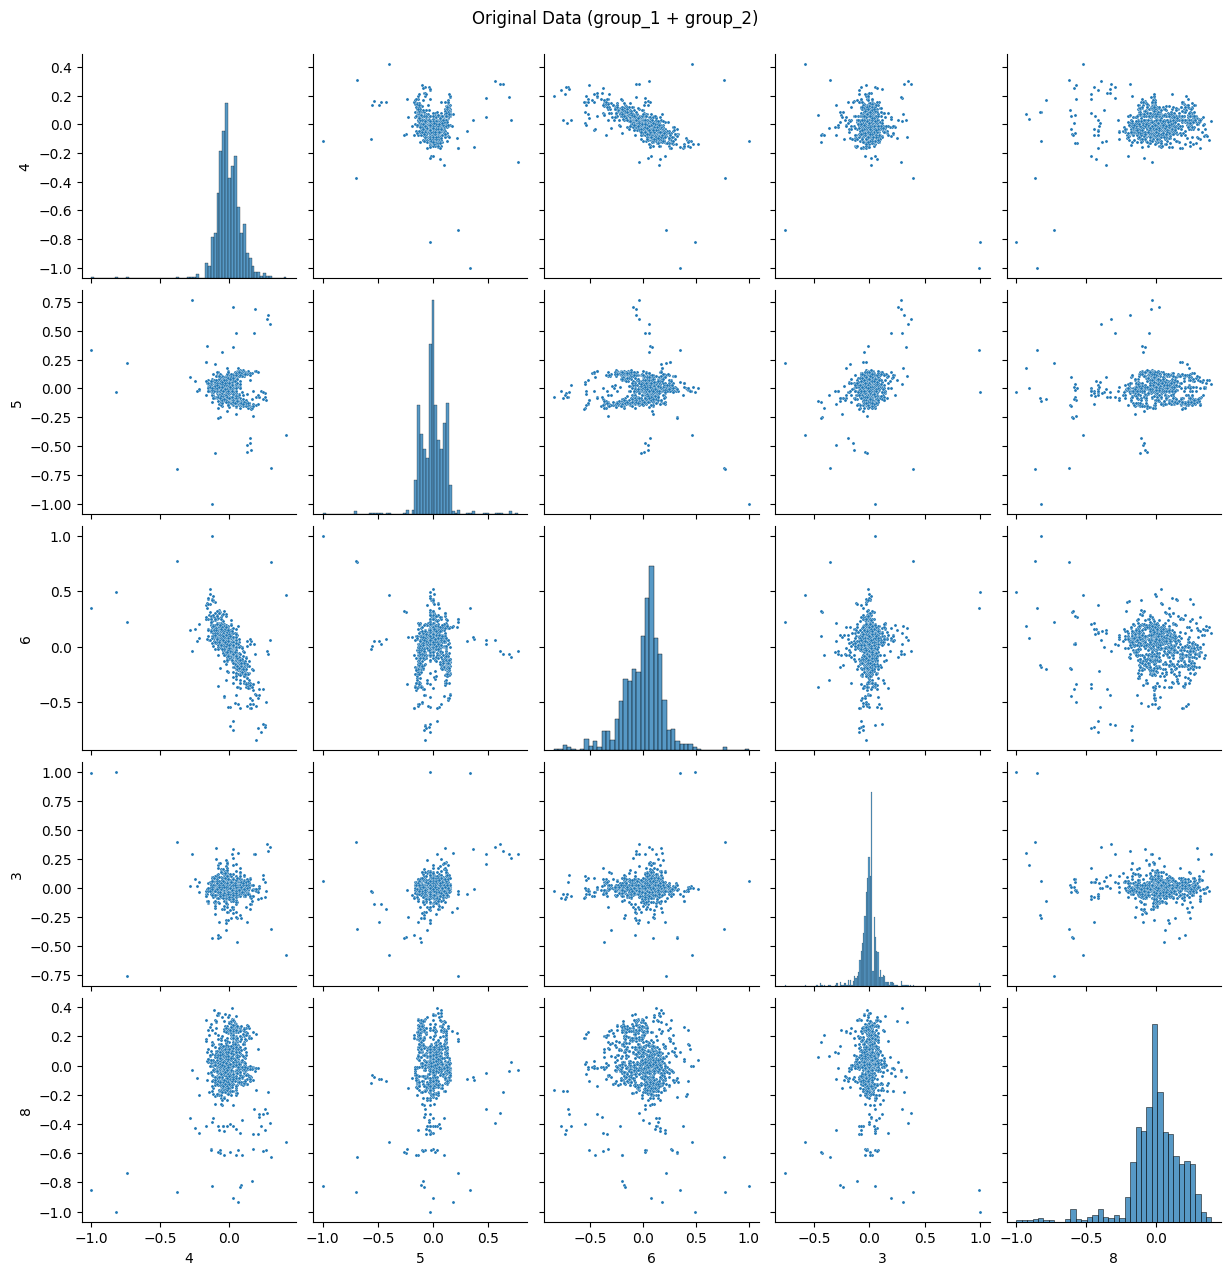

In [ ]:
# Combine the raw input data
combined_data = pd.concat([group_1.reset_index(drop=True), group_2.reset_index(drop=True)], axis=1)
#combined_data.columns = [f"X1_{i}" for i in range(group_1.shape[1])] + [f"X2_{i}" for i in range(group_2.shape[1])]

# First pairplot: original data
g1 = sns.pairplot(combined_data, plot_kws={'s': 5})
g1.fig.suptitle("Original Data (group_1 + group_2)", y=1.02)

# Save axis limits from first plot
lims = {}
for i, row_axes in enumerate(g1.axes):
    for j, ax in enumerate(row_axes):
        if ax:
            lims[(i, j)] = (ax.get_xlim(), ax.get_ylim())

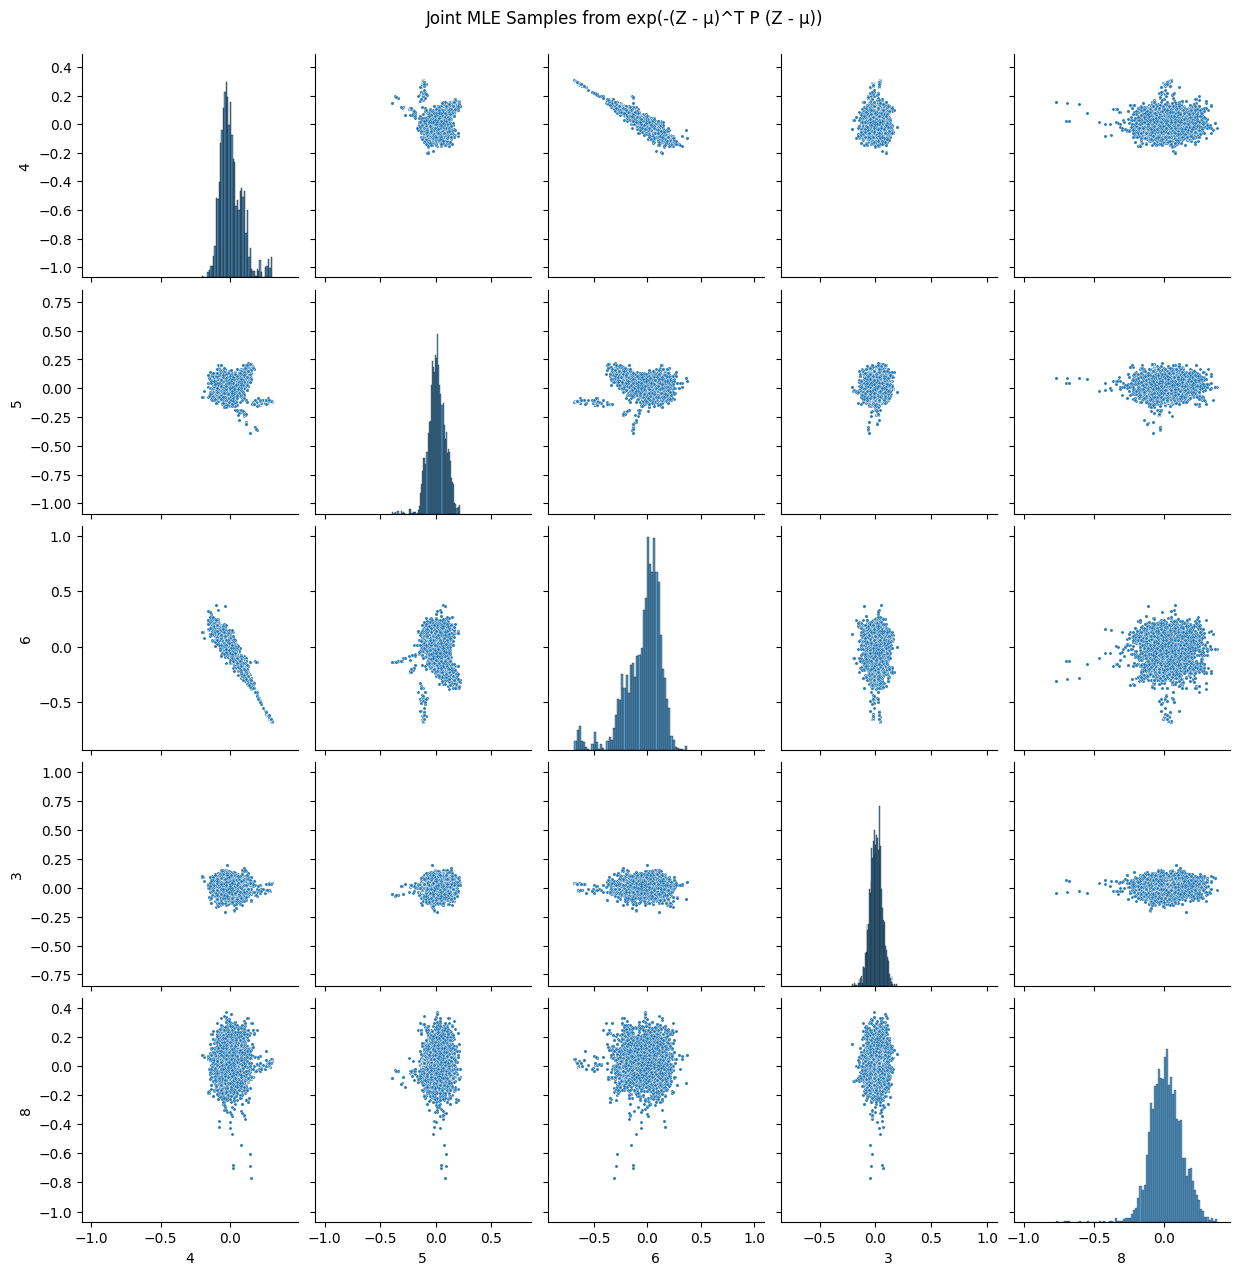

In [ ]:
# Second pairplot: MCMC samples
g2 = sns.pairplot(samples, plot_kws={'s': 5})
g2.fig.suptitle("Joint MLE Samples from exp(-(Z - μ)^T P (Z - μ))", y=1.02)

# Apply saved limits to second plot
for i, row_axes in enumerate(g2.axes):
    for j, ax in enumerate(row_axes):
        if ax and (i, j) in lims:
            ax.set_xlim(lims[(i, j)][0])
            ax.set_ylim(lims[(i, j)][1])

### Dependency Optimization

In [ ]:
mu,P = combine_B_blocks_reparam(B1, B2,
                             group_1, group_2,
                             degree=3, n_grid=10000,
                             verbosity=2, max_iterations=1000,
                             min_gradient_norm=1e-2,
                             n_restarts=0,
                             winsor_threshold=1e-3)

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
   1         -6.9077552789821368e+00    6.48833929e-01    
   2         -7.0379303406068052e+00    4.16570193e-01    
   3         -7.0685598029218388e+00    3.69004223e-01    
   4         -7.0760993651965247e+00    3.57737806e-01    
   5         -7.0779769217067781e+00    3.54959325e-01    
   6         -7.0784458529028802e+00    3.54267073e-01    
   7         -7.0785630570881750e+00    3.54094158e-01    
   8         -7.0785703822379853e+00    3.54083353e-01    
   9         -7.0785740447849479e+00    3.54077950e-01    
  10         -7.0785758760514437e+00    3.54075249e-01    
  11         -7.0785767916829450e+00    3.54073898e-01    
  12         -7.0785767925771168e+00    3.54073897e-01    
  13         -7.0785767930242027e+00    3.54073896e-01    
Terminated - min step_size reached after 13 iterations, 0.75 seconds.



In [ ]:
loglike_combined(group_1, group_2, mu, P, degree=3, n_grid=1000, winsor=1e-3) #smaller negative log-likelihood

np.float64(1435.7852803366877)

In [ ]:
samples_dep = sample_from_joint_poly_density(group_1, group_2, mu, P, 3,
                                    num_samples=1000, burnin=200, thin=1, nwalkers=None)

100%|██████████| 1000/1000 [00:04<00:00, 212.33it/s]


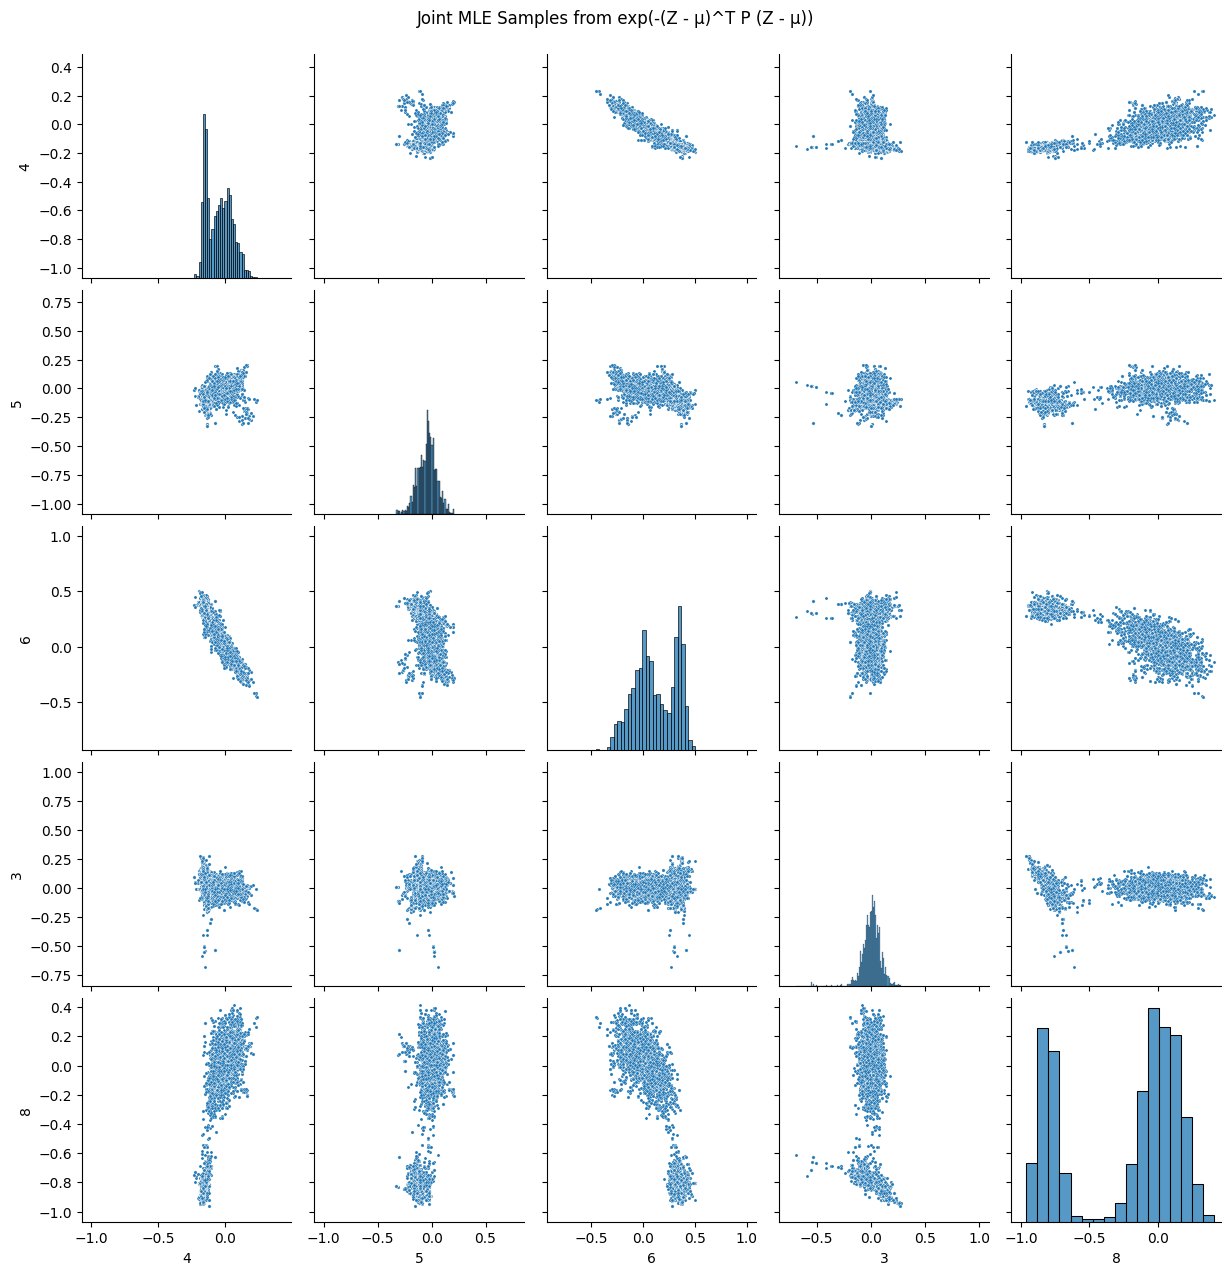

In [ ]:
# Third pairplot: MCMC samples for dependent
g2 = sns.pairplot(samples_dep, plot_kws={'s': 5})
g2.fig.suptitle("Joint MLE Samples from exp(-(Z - μ)^T P (Z - μ))", y=1.02)

# Apply saved limits to second plot
for i, row_axes in enumerate(g2.axes):
    for j, ax in enumerate(row_axes):
        if ax and (i, j) in lims:
            ax.set_xlim(lims[(i, j)][0])
            ax.set_ylim(lims[(i, j)][1])